## Introduction to Quantum Computing: Labs

### Lab 8: Parameterized Quantum Circuits

In this lab, we study a complete small workflow for variational quantum computing. We will

1. build a parameterized quantum circuit,
2. evaluate expectation values with Qiskit Estimator routines,
3. inspect how the circuit output changes when parameters change,
4. minimize an expectation value without gradients, and
5. minimize an expectation value with gradients.

The central object is a parameterized quantum state

$$
|\psi(\theta)\rangle = U(\theta)|0\rangle,
$$

and the model output is an expectation value

$$
f(\theta) = \langle\psi(\theta)|O|\psi(\theta)\rangle.
$$

Here, $U(\theta)$ is the parameterized circuit and $O$ is an observable.
The notebook is structured into small steps. Most exercises require only a few lines of code. The goal is not to write long Python programs, but to understand the quantum computing objects and the typical workflow of variational quantum algorithms.

From Exercise 2 onward, we use the helper functions from `qc_lecture_tools.expectation_value`:

>```python
>evaluate_expectation_value()
>gradient_finite_differences()
>gradient_parameter_shift_rule()
>```


### Imports

Run this cell first. The Qiskit Estimator primitives are imported later, in the exercises where they are needed.


In [85]:
import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
from qiskit.quantum_info import SparsePauliOp

from scipy.optimize import minimize

from qc_lecture_tools.expectation_value import (
    evaluate_expectation_value,
    gradient_finite_differences,
    gradient_parameter_shift_rule,
)


### Exercise 1: Inspecting the ansatz circuit

**Helper: parameterized quantum circuit**

We use the same simple hardware-efficient ansatz throughout the lab.
The function below is provided as a helper.


In [86]:
def parametrized_circuit(num_qubits: int = 2, num_layers: int = 1) -> QuantumCircuit:
    """Create a hardware-efficient parameterized quantum circuit.

    Args:
        num_qubits: Number of qubits.
        num_layers: Number of repeated Ry-CX layers.

    Returns:
        The parameterized quantum circuit.
    """
    parameters = ParameterVector("p", length=num_layers * num_qubits)
    circuit = QuantumCircuit(num_qubits)

    circuit.h(range(num_qubits))

    parameter_index = 0
    for _ in range(num_layers):
        for qubit in range(num_qubits):
            circuit.ry(parameters[parameter_index], qubit)
            parameter_index += 1

        for qubit in range(num_qubits):
            circuit.cx(qubit, (qubit + 1) % num_qubits)

    return circuit


**Exercise 1:**

Create a circuit with `5` qubits and `2` layers and draw it.

While inspecting the circuit, answer the following questions:

- How many parameters does the circuit have?
- Where are the CX gates placed?
- Why does the last CX gate connect the last qubit back to qubit `0`?


In [87]:
# TODO Exercise 1


### Exercise 2: Expectation values with Qiskit Estimator routines

In variational quantum algorithms, the quantum circuit usually does not directly return the final answer as a bit string. Instead, the circuit prepares a quantum state, and we evaluate the expectation value of an observable.

In this exercise, we compute expectation values directly with Qiskit's Estimator routines. Later, the same logic will be hidden inside the helper function `evaluate_expectation_value`.

We use the following two-qubit observable and a two-qubit parameterized circuit.


Number of parameters: 4
Parameters: [0.5488135  0.71518937 0.60276338 0.54488318]


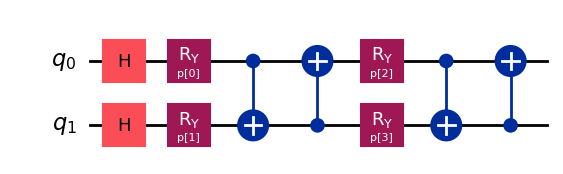

In [ ]:
observable_2q = SparsePauliOp(
    data=["ZZ", "IZ", "ZI", "II", "XX", "YY"],
    coeffs=[
        0.0934565 + 0.0j,
        0.0934565 + 0.0j,
        -0.03564482 + 0.0j,
        -0.84457058 + 0.0j,
        -0.05738398 + 0.0j,
        -0.05738398 + 0.0j,
    ],
)

quantum_circuit_2 = parametrized_circuit(num_qubits=2, num_layers=2)

np.random.seed(0)
parameters = np.random.rand(quantum_circuit_2.num_parameters)

print("Number of parameters:", quantum_circuit_2.num_parameters)
print("Parameters:", parameters)
quantum_circuit_2.draw("mpl")


**Exercise 2.1:** Exact expectation value with `StatevectorEstimator`

The `StatevectorEstimator` computes the exact expectation value by simulating the full statevector. This is useful for debugging because it does not include measurement noise.

The Estimator receives a list of jobs. In this notebook, each job is a tuple of the form

```python
(circuit, observable, parameter_values)
```

Your tasks:

1. Import `StatevectorEstimator` from `qiskit.primitives`.
2. Create an estimator object. No input arguments are needed.
3. Call `estimator.run([(quantum_circuit, observable_2q, parameters)])`.
4. Extract the expectation value from `result[0].data.evs`.

The result should be approximately `-1.05493392144`.


In [89]:
from qiskit.primitives import StatevectorEstimator

# TODO Exercise 2.1

**Exercise 2.2: Expectation value with finite shots**

On real hardware, expectation values are estimated from measurements. Here, we simulate this behavior with the local `aer_simulator` backend and `EstimatorV2`.

The number of shots is controlled indirectly through the `default_precision` option:

$$
\texttt{default\_precision} = \frac{1}{\sqrt{N_\text{shots}}}.
$$

Choose a number of shots in the code below and run the cell several times.

Questions to investigate:

- How much does the shot-based estimate fluctuate?
- What changes when you increase the number of shots?
- How many shots do you need so that the first two digits remain stable when you rerun the cell several times?


In [ ]:
from qiskit_aer import Aer
from qiskit_ibm_runtime import EstimatorV2


backend = Aer.get_backend("aer_simulator")

shots = 1  # TODO Exercise 2.2: choose the number of shots

estimator = EstimatorV2(
    mode=backend,
    options={"default_precision": 1 / np.sqrt(shots)},
)

result = estimator.run([(quantum_circuit_2, observable_2q, parameters)]).result()
expectation_shots = float(result[0].data.evs)

print("Exact expectation value: ", -1.0549339214407079)
print("Shot-based estimate:    ", expectation_shots)


Exact expectation value:  -1.0549339214407079
Shot-based estimate:     -0.9236937199999998


**Exercise 2.3: Expectation value on a simulated hardware backend**

For a hardware backend, the circuit must be transpiled so that it matches the backend's available gates and qubit connectivity.

There is one important additional step for the observable: after transpilation, the layout of the qubits may change.

Therefore, the observable must be adapted to the new layout:

>```python
>observable_mapped = observable_2q.apply_layout(transpiled_circuit.layout)
>```

Your tasks:

1. Create the fake backend `FakeManilaV2()`.
2. Transpile the parameterized circuit for this backend using

   >```python
   >transpiled_circuit = transpile(quantum_circuit, backend=backend)
   >```

3. Adapt the observable with `apply_layout` and print the transformed observable.
4. Use `EstimatorV2` to evaluate the expectation value with the same number of shots as in Exercise 2.2 that keep the first two digits stable. Use the fake backend as the `mode`.

Run the cell several times to get a feeling for the fluctuations.

How does the result compare with the exact expectation value? 


In [91]:
from qiskit_ibm_runtime.fake_provider import FakeManilaV2
from qiskit.compiler import transpile

# TODO Exercise 2.3

**Exercise 2.4: Optional real backend**

The code structure for a real backend is almost the same. Only the backend object changes.

The following cell is commented out because access to real IBM Quantum hardware requires an account, a token, and queue time.


In [ ]:
# from qiskit_ibm_runtime import QiskitRuntimeService

# service = QiskitRuntimeService(channel="ibm_cloud", token="INSERT TOKEN HERE")
# backend_fez = service.backend("ibm_fez")

# transpiled_circuit = transpile(quantum_circuit_2, backend=backend_fez)
# transpiled_observable = observable_2q.apply_layout(transpiled_circuit.layout)

# estimator = EstimatorV2(
#     mode=backend_fez,
#     options={"default_precision": 1 / np.sqrt(1024)},
# )

# result = estimator.run(
#     [(transpiled_circuit, transpiled_observable, parameters)]
# ).result()
# float(result[0].data.evs)


### Exercise 3: Outputs of a parameterized quantum circuit

From now on, use the helper function `evaluate_expectation_value`.

This function performs the Estimator logic from Exercise 2 for us. In particular, it can handle exact simulation, finite-shot simulation, and simulated hardware backends:

>```python
>evaluate_expectation_value(circuit, observable, parameters)
>evaluate_expectation_value(circuit, observable, parameters, shots=1000)
>evaluate_expectation_value(circuit, observable, parameters, shots=1000, backend=FakeManilaV2())
>```


**Exercise 3.1: Plot the output for exact simulation, shot noise, and simulated hardware**

In this exercise, we vary only the first parameter $\theta_0$ and keep the remaining parameters fixed.

The plotting code is already prepared. Your tasks are to replace the three placeholder values in the loop by the corresponding calls to `evaluate_expectation_value`:

1. exact simulation,
2. finite-shot simulation with `shots=1000`,
3. finite-shot simulation on the fake backend with `shots=1000` and `backend=backend`.

Afterwards, compare the three curves. Which effects are caused by shot noise, and which effects are caused by the backend model?


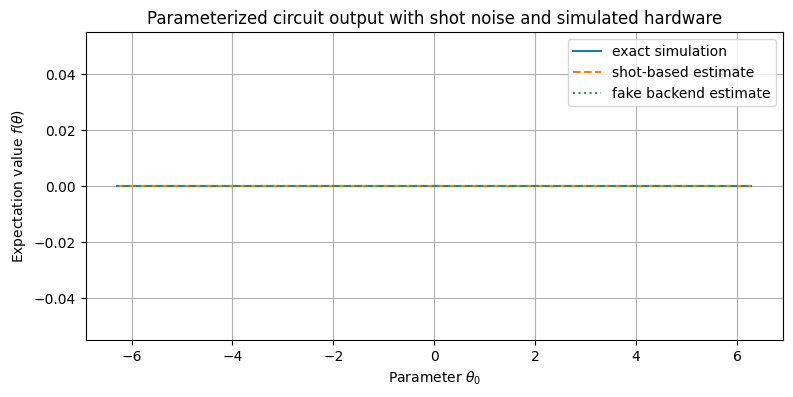

In [93]:
from qiskit_ibm_runtime.fake_provider import FakeManilaV2

backend = FakeManilaV2()

quantum_circuit = parametrized_circuit(num_qubits=2, num_layers=2)
parameter_values = np.random.rand(quantum_circuit.num_parameters)
theta_values = np.linspace(-2 * np.pi, 2 * np.pi, 41)

values_exact = []
values_shots = []
values_fake_backend = []

for theta0 in theta_values:
    parameter_values[0] = theta0

    value_exact = 0.0  # TODO Exercise 3.1: exact expectation value
    values_exact.append(value_exact)

    value_shots = 0.0  # TODO Exercise 3.1: expectation value with shots=1000
    values_shots.append(value_shots)

    value_fake_backend = 0.0  # TODO Exercise 3.1: expectation value with shots=1000 and backend=backend
    values_fake_backend.append(value_fake_backend)

plt.figure(figsize=(9, 4))
plt.plot(theta_values, values_exact, label="exact simulation")
plt.plot(theta_values, values_shots, label="shot-based estimate", linestyle="dashed")
plt.plot(theta_values, values_fake_backend, label="fake backend estimate", linestyle="dotted")
plt.xlabel(r"Parameter $\theta_0$")
plt.ylabel(r"Expectation value $f(\theta)$")
plt.title("Parameterized circuit output with shot noise and simulated hardware")
plt.legend()
plt.grid(True)
plt.show()


**Exercise 3.2: Two-dimensional output landscape**

With two active parameters, the output is already a function of two variables. The following code creates a heatmap.

Initially, the code varies parameters `0` and `1`:

```python
parameter_values[0] = theta_x
parameter_values[1] = theta_y
```

Your task is to change `parameter_index_x` and `parameter_index_y` and observe how the landscape changes by rerunning the cell.

Questions to investigate:

- Do neighboring parameters lead to similar landscapes?
- What changes if you vary parameters from different layers?
- Are there flat regions or strong oscillations?


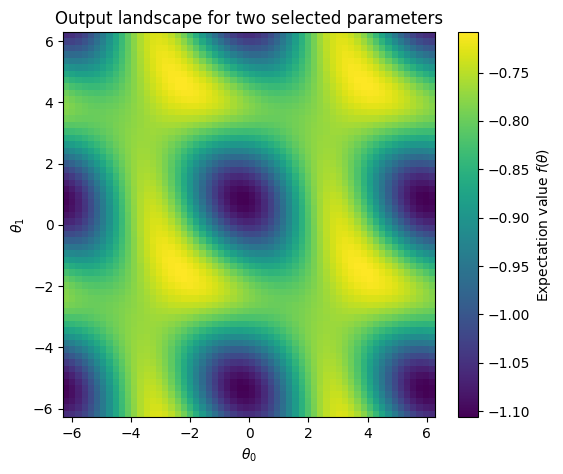

In [94]:
theta_grid = np.linspace(-2 * np.pi, 2 * np.pi, 60)
values_grid = np.zeros((len(theta_grid), len(theta_grid)))

base_parameters = np.random.rand(quantum_circuit.num_parameters)

parameter_index_x = 0  # TODO Exercise 3.2: change this index and replot
parameter_index_y = 1  # TODO Exercise 3.2: change this index and replot

for i, theta_x in enumerate(theta_grid):
    for j, theta_y in enumerate(theta_grid):
        parameter_values = base_parameters.copy()
        parameter_values[parameter_index_x] = theta_x
        parameter_values[parameter_index_y] = theta_y

        values_grid[j, i] = evaluate_expectation_value(
            quantum_circuit,
            observable_2q,
            parameter_values,
        )

plt.figure(figsize=(6, 5))
plt.imshow(
    values_grid,
    origin="lower",
    extent=[theta_grid[0], theta_grid[-1], theta_grid[0], theta_grid[-1]],
    aspect="auto",
)
plt.colorbar(label=r"Expectation value $f(\theta)$")
plt.xlabel(rf"$\theta_{{{parameter_index_x}}}$")
plt.ylabel(rf"$\theta_{{{parameter_index_y}}}$")
plt.title("Output landscape for two selected parameters")
plt.show()


### Exercise 4: Optimization of the expectation value without gradients

We now use the parameterized circuit as a variational ansatz for a small VQE-style problem.

The observable below is a simple molecular model for $\mathrm{H}_2$. The smallest eigenvalue of this observable is the best possible value if we could prepare the exact eigenstate. In a variational algorithm, we try to get close to this value by optimizing the circuit parameters.

We will discuss the physical interpretation in more detail later, in the chapter on quantum simulation. For now, you can view the observable as the cost function that we want to minimize.


In [95]:
observable_h2 = SparsePauliOp(
    data=[
        "ZZIZ", "IZZI", "IIZI", "IIIZ", "IIII",
        "ZIZZ", "ZZZZ", "ZZII", "IZII", "IZZZ",
        "IIZZ", "IIII", "IIXX", "IZYY", "ZZYY",
        "ZIXX",
    ],
    coeffs=[
        0.0934565 + 0.0j,
        0.0934565 + 0.0j,
        -0.03564482 + 0.0j,
        -0.03564482 + 0.0j,
        -0.84457058 + 0.0j,
        0.13817585 + 0.0j,
        0.08253705 + 0.0j,
        0.13992104 + 0.0j,
        0.13992104 + 0.0j,
        0.08253705 + 0.0j,
        0.14585519 + 0.0j,
        0.35278481 + 0.0j,
        -0.05738398 + 0.0j,
        -0.05738398 + 0.0j,
        -0.05738398 + 0.0j,
        -0.05738398 + 0.0j,
    ],
)

eigenvalues = np.linalg.eigh(observable_h2.to_matrix()).eigenvalues
ground_state_energy = np.min(eigenvalues)

print("Smallest eigenvalue:", ground_state_energy)


Smallest eigenvalue: -0.9981493346131962


**Exercise 4.1: One gradient-free optimization with COBYLA**

We first optimize without gradients. The optimizer only asks for function values.

The optimization setup is already implemented, but the quantum part of the objective function is missing.

Your tasks:

1. In the objective function, evaluate the expectation value of `observable_h2` with `evaluate_expectation_value`.
2. Run the optimizer and compare the best value with the smallest eigenvalue printed above.

COBYLA is a gradient-free optimizer. It can be useful when gradients are unavailable, but it may need many function evaluations.

In [ ]:
num_layers = 1
quantum_circuit_41 = parametrized_circuit(num_qubits=4, num_layers=num_layers)

np.random.seed(0)
theta0 = np.random.rand(quantum_circuit_41.num_parameters)

history_cobyla = []


def objective(parameters: np.ndarray) -> float:
    value = 0.0  # TODO Exercise 4.1: replace 0.0 and evaluate the expectation value without shots
    history_cobyla.append(value)
    return value


result_cobyla = minimize(
    fun=objective,
    x0=theta0,
    method="COBYLA",
    options={"maxiter": 200},
)

print("COBYLA:")
print(" f(theta*) =", result_cobyla.fun)
print(" nfev =", result_cobyla.nfev)
print(" smallest eigenvalue =", ground_state_energy)


COBYLA:
 f(theta*) = 0.0
 nfev = 25
 smallest eigenvalue = -0.9981493346131962


**Exercise 4.2: Effect of the number of layers**

The following code displays the optimization history from Exercise 4.1.

Repeat Exercise 4.1 with `num_layers = 2` and `num_layers = 3`. After each run, plot the optimization history again.

Questions to investigate:

- Does the final value improve when you add more layers?
- Does the optimization become easier or harder?
- How does the number of parameters change?


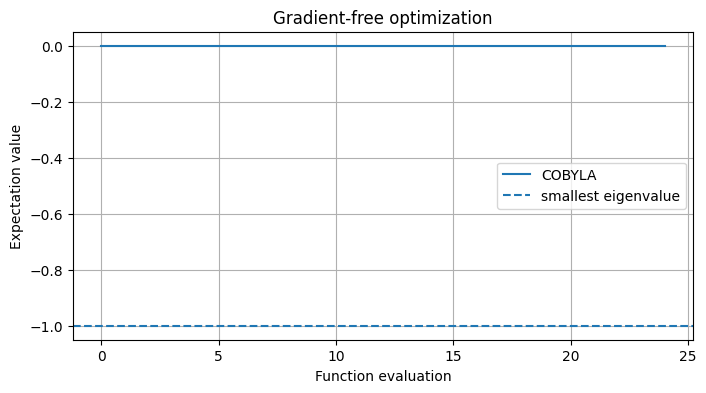

In [97]:
plt.figure(figsize=(8, 4))
plt.plot(history_cobyla, label="COBYLA")
plt.axhline(ground_state_energy, linestyle="--", label="smallest eigenvalue")
plt.xlabel("Function evaluation")
plt.ylabel("Expectation value")
plt.title("Gradient-free optimization")
plt.legend()
plt.grid(True)
plt.show()


**Exercise 4.3: Gradient-free optimization with finite shots**

Now repeat the COBYLA optimization for `num_layers = 3`, but estimate each expectation value with a finite number of measurements.

Use `10000` shots in the call to `evaluate_expectation_value`.

Compare the optimization history with the exact run, which is plotted in the next cell (no changes in the code needed). For a fair comparison, rerun the exact COBYLA optimization with `num_layers = 3` before running the comparison plot.


In [ ]:
num_layers = 3
quantum_circuit_43 = parametrized_circuit(num_qubits=4, num_layers=num_layers)

np.random.seed(0)
theta0 = np.random.rand(quantum_circuit_43.num_parameters)

shots = 10000
history_cobyla_shots = []


def objective(parameters: np.ndarray) -> float:
    value = 0.0  # TODO Exercise 4.3: evaluate the expectation value with shots=shots
    history_cobyla_shots.append(value)
    return value


result_cobyla = minimize(
    fun=objective,
    x0=theta0,
    method="COBYLA",
    options={"maxiter": 200},
)

print("COBYLA:")
print(" f(theta*) =", result_cobyla.fun)
print(" nfev =", result_cobyla.nfev)
print(" smallest eigenvalue =", ground_state_energy)


COBYLA:
 f(theta*) = 0.0
 nfev = 73
 smallest eigenvalue = -0.9981493346131962


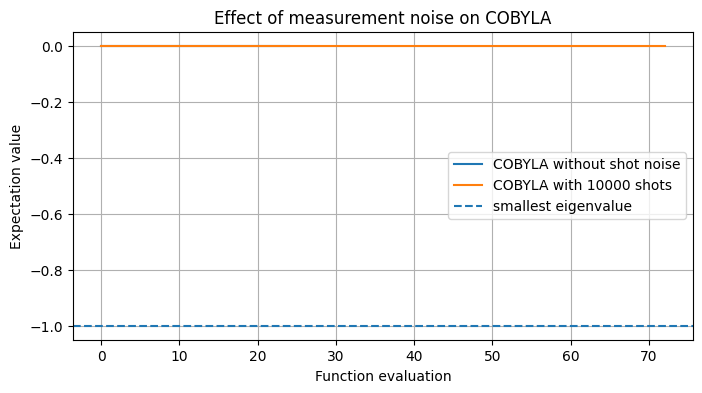

In [99]:
plt.figure(figsize=(8, 4))
plt.plot(history_cobyla, label="COBYLA without shot noise")
plt.plot(history_cobyla_shots, label="COBYLA with 10000 shots")
plt.axhline(ground_state_energy, linestyle="--", label="smallest eigenvalue")
plt.xlabel("Function evaluation")
plt.ylabel("Expectation value")
plt.title("Effect of measurement noise on COBYLA")
plt.legend()
plt.grid(True)
plt.show()


### Exercise 5: Optimization of the expectation value with gradients

Gradient-based optimization uses not only the function value, but also information about the direction in which the function changes.

For a function with many parameters,

$$
f(\theta_1, \theta_2, \dots, \theta_n),
$$

the gradient is the vector of partial derivatives:

$$
\nabla f(\theta) =
\begin{pmatrix}
\frac{\partial f}{\partial \theta_1} \\
\frac{\partial f}{\partial \theta_2} \\
\vdots \\
\frac{\partial f}{\partial \theta_n}
\end{pmatrix}.
$$

In this lab, we do not implement the gradients manually. We use the prepared helper functions.

#### Finite differences

Numerically, the derivative in one dimension can be approximated, for example, with the central difference:

$$
\frac{\partial f}{\partial \theta_i} \approx \frac{f(\theta_i + h) - f(\theta_i - h)}{2h}.
$$

The smaller $h$ is, the better this approximation becomes in exact arithmetic. In practice, very small values of $h$ can cause numerical problems, and finite-shot noise can be strongly amplified.

The finite-difference gradient can be calculated with `gradient_finite_differences`, which takes almost the same input arguments as `evaluate_expectation_value`:

>```python
>gradient_fd = gradient_finite_differences(
>    quantum_circuit,
>    observable,
>    parameters,
>    delta_h=0.01,
>    shots=None,
>)
>```

#### Parameter-shift rule

The parameter-shift rule is especially important for quantum circuits. For many rotation gates, it gives the derivative exactly in the ideal case:

$$
\frac{\partial f}{\partial \theta_i}
=
\frac{f(\theta_i + \pi/2) - f(\theta_i - \pi/2)}{2},
$$

where all other parameters are kept fixed.

The parameter-shift gradient can be computed with `gradient_parameter_shift_rule`:

>```python
>gradient_ps = gradient_parameter_shift_rule(
>    quantum_circuit,
>    observable,
>    parameters,
>    shots=None,
>)
>```


**Exercise 5.1: Compare two ways of computing gradients**

Generate a quantum circuit with two qubits and a single layer. Choose random values for the parameters.

Your tasks:

1. Compute the gradient with finite differences.
2. Compute the gradient with the parameter-shift rule.
3. Compare both gradients in exact simulation.
4. Repeat the comparison with a finite number of shots.

Questions to investigate:

- How close are the two gradients in exact simulation?
- Which method becomes noisier when finite shots are used?
- Why does dividing by a small value of `delta_h` amplify noise?


In [ ]:
quantum_circuit_51 = parametrized_circuit(num_qubits=2, num_layers=1)

np.random.seed(0)
parameters = np.random.rand(quantum_circuit_51.num_parameters)

# TODO Exercise 5.1


**Exercise 5.2: Gradient-based optimization with exact expectation values**

Now use the gradient in the optimizer. We use the `SLSQP` method from SciPy and pass the gradient function through the argument `jac=`.

The objective function and the gradient function are already prepared, but the quantum computations are missing.

Your tasks:

1. In `objective`, compute the exact expectation value with `evaluate_expectation_value`.
2. In `gradient`, compute the exact gradient with `gradient_parameter_shift_rule`.
3. Run the optimizer and compare the result with the COBYLA optimization.


In [ ]:
num_layers = 3
quantum_circuit_52 = parametrized_circuit(num_qubits=4, num_layers=num_layers)

np.random.seed(0)
theta0 = np.random.rand(quantum_circuit_52.num_parameters)

history_slsqp = []
gradient_norms_slsqp = []


def objective(parameters: np.ndarray) -> float:
    value = 0.0  # TODO Exercise 5.2: evaluate the expectation value without shots
    history_slsqp.append(value)
    return value


def gradient(parameters: np.ndarray) -> np.ndarray:
    grad = np.zeros(quantum_circuit_52.num_parameters)  # TODO Exercise 5.2: replace the np.zeros function with the actual parameter-shift gradient without shots
    gradient_norms_slsqp.append(np.linalg.norm(grad))
    return grad


result_slsqp = minimize(
    fun=objective,
    x0=theta0,
    method="SLSQP",
    jac=gradient,
    options={"maxiter": 100},
)

print("SLSQP:")
print(" f(theta*) =", result_slsqp.fun)
print(" nfev =", result_slsqp.nfev)
print(" njev =", result_slsqp.njev)
print(" smallest eigenvalue =", ground_state_energy)


SLSQP:
 f(theta*) = 0.0
 nfev = 1
 njev = 1
 smallest eigenvalue = -0.9981493346131962


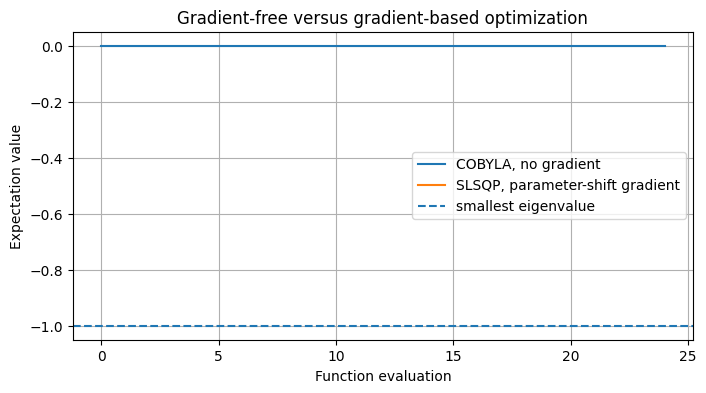

In [102]:
plt.figure(figsize=(8, 4))
plt.plot(history_cobyla, label="COBYLA, no gradient")
plt.plot(history_slsqp, label="SLSQP, parameter-shift gradient")
plt.axhline(ground_state_energy, linestyle="--", label="smallest eigenvalue")
plt.xlabel("Function evaluation")
plt.ylabel("Expectation value")
plt.title("Gradient-free versus gradient-based optimization")
plt.legend()
plt.grid(True)
plt.show()


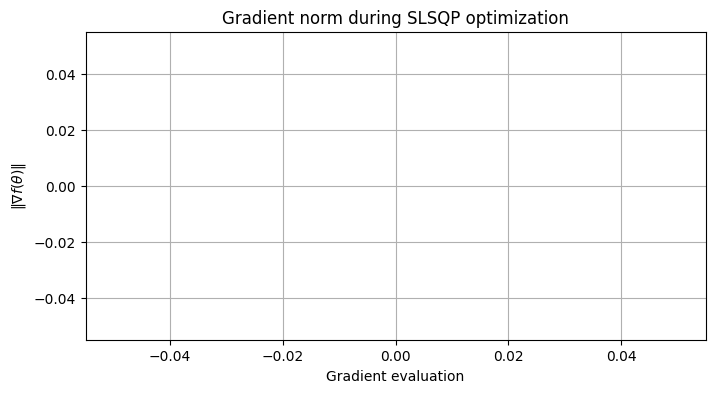

In [103]:
plt.figure(figsize=(8, 4))
plt.plot(gradient_norms_slsqp)
plt.xlabel("Gradient evaluation")
plt.ylabel(r"$\|\nabla f(\theta)\|$")
plt.title("Gradient norm during SLSQP optimization")
plt.grid(True)
plt.show()


**Exercise 5.3: Gradient-based optimization with finite shots**

Finally, we repeat gradient-based optimization with a finite number of measurements.

The `SLSQP` optimizer is usually not robust against noisy function and gradient values. Therefore, we use the provided `adam_minimize` helper. ADAM is commonly used in machine learning and is often more robust when gradient estimates are noisy.

Your tasks:

1. In `objective`, compute the expectation value with `shots=1000`.
2. In `gradient`, compute the parameter-shift gradient with `shots=1000`.
3. Run the optimization and inspect the result.


In [ ]:
from qc_lecture_tools.optimization import adam_minimize

num_layers = 3
quantum_circuit_53 = parametrized_circuit(num_qubits=4, num_layers=num_layers)

np.random.seed(0)
theta0 = np.random.rand(quantum_circuit_53.num_parameters)

shots = 1000
history_adam = []
gradient_norms_adam = []


def objective(parameters: np.ndarray) -> float:
    value = 0.0  # TODO Exercise 5.3: evaluate the expectation value with shots=shots
    history_adam.append(value)
    return value


def gradient(parameters: np.ndarray) -> np.ndarray:
    grad = np.zeros(quantum_circuit_53.num_parameters)  # TODO Exercise 5.3: parameter-shift gradient with shots=shots
    gradient_norms_adam.append(np.linalg.norm(grad))
    return grad


result_adam = adam_minimize(
    fun=objective,
    x0=theta0,
    jac=gradient,
)

print("ADAM:")
print(" f(theta*) =", result_adam.fun)
print(" nfev =", result_adam.nfev)
print(" smallest eigenvalue =", ground_state_energy)


ADAM:
 f(theta*) = 0.0
 nfev = 1
 smallest eigenvalue = -0.9981493346131962


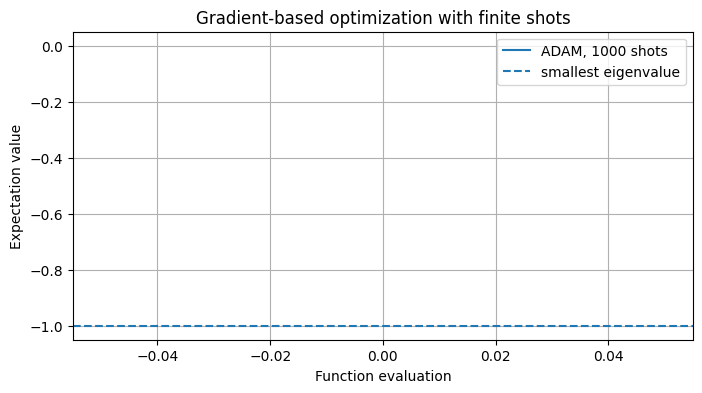

In [105]:
plt.figure(figsize=(8, 4))
plt.plot(history_adam, label="ADAM, 1000 shots")
plt.axhline(ground_state_energy, linestyle="--", label="smallest eigenvalue")
plt.xlabel("Function evaluation")
plt.ylabel("Expectation value")
plt.title("Gradient-based optimization with finite shots")
plt.legend()
plt.grid(True)
plt.show()
